In [1]:
from math import ceil
#from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from flups.io import load_txt, save_txt
from flups.analysis import despike_median, shift_trace
from pyspan.utils import nm2ev, between, argnear
#from ipywidgets import interact, interactive, fixed, interact_manual, GridspecLayout, AppLayout, Button
import ipywidgets as widgets
#from numpy.polynomial import Polynomial
#from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.spatial.distance import cdist, correlation
import colorcet as cc
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter
#import scistyles

In [2]:
%matplotlib widget
#plt.style.use("report-sp")

# Select files

In [3]:
#  select files
nums = range(1,5)
fnames = [f"240624_run{i:02d}.txt" for i in nums]
# setup an output root file name
out_root = fnames[0][:-6]+f"{nums[0]:02d}{nums[-1]:02d}"
fnames, out_root

(['240624_run01.txt',
  '240624_run02.txt',
  '240624_run03.txt',
  '240624_run04.txt'],
 '240624_run0104')

In [4]:
# Load all ta_data into a dictionnary. It maps {fn: (t, wl, dod)}
dat = {fn: load_txt(fn) for fn in fnames}
# this should not be necessary in the future
for fn, (t, wl, s) in dat.items():
    if t[1]<t[0]:
        t = t[::-1]
        s = s[::-1,:]
    s = s.T
    dat[fn] = (t, wl, s)
    

In [5]:
# Check all times are the same
all_t = np.array([d[0] for d in dat.values()])
assert np.allclose(all_t[0], all_t)
t = all_t[0]
# Check all wavelengths are the same
all_wl = np.array([d[1] for d in dat.values()])
assert np.allclose(all_wl[0], all_wl)
wl = all_wl[0]
pix = np.arange(wl.size)
if np.allclose(wl, np.arange(wl.size)+1): # convert pixels to energy
    wl_u = pix*0.123+244.284

# Load all the delta A data.
sig = np.array([d[2] for d in dat.values()])
org = sig.copy()


# plot the traces

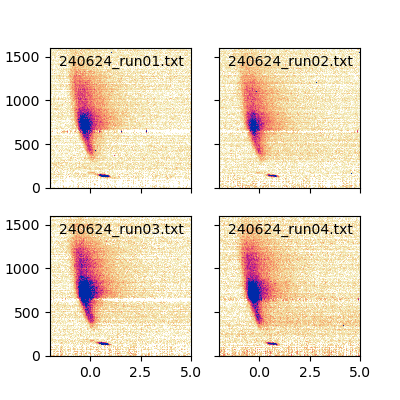

In [6]:
# Setup two columns.
nrows = ceil(len(fnames)/2)
fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=True, sharey=True, figsize=(4,nrows*2))

# You can modify the limits of the colormap here
vmin, vmax = np.percentile(sig, [10, 99])


# plot the trace for all filenames
for i, (fn, ax) in enumerate(zip(fnames, axes.flat)):
    plt.sca(ax)
    plt.pcolormesh(t, pix, sig[i,:,:], cmap="cet_CET_L17", vmin=vmin, vmax=vmax)
    plt.text(0.95, 0.95, fnames[i], transform=ax.transAxes, va="top", ha="right")


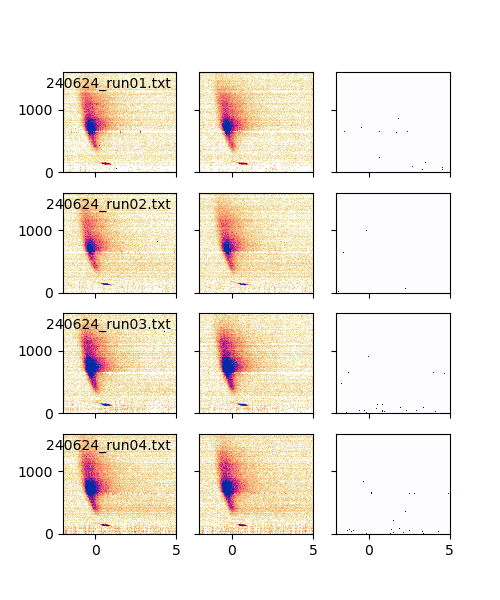

In [7]:
# Cosmic spike removal.
# Setup two columns.
nrows = len(fnames)
fig, axes = plt.subplots(nrows=nrows, ncols=3, sharex=True, sharey=True, figsize=(5,nrows*1.5))
axes = np.atleast_2d(axes)
# You can modify the limits of the colormap here
vmin, vmax = np.percentile(sig, [10, 99])

lo, hi = np.percentile(sig.compress(t<-1.4, axis=2), [2.5, 97.5])
thres = (hi-lo)

filter_len = (11,3)

filt = []
# plot the trace for all filenames
for i, fn in enumerate(fnames):
    
    filt.append(despike_median(sig[i,:,:], filter_len, threshold=thres))
    plt.sca(axes[i,0])
    plt.pcolormesh(t, pix, sig[i,:,:], cmap="cet_CET_L17", vmin=vmin, vmax=vmax)
    plt.text(0.95, 0.95, fnames[i], transform=plt.gca().transAxes, va="top", ha="right")
    plt.sca(axes[i,1])
    plt.pcolormesh(t, pix, filt[i], cmap="cet_CET_L17", vmin=vmin, vmax=vmax)
    plt.sca(axes[i,2])
    plt.pcolormesh(t, pix, sig[i,:,:]-filt[i], cmap="seismic_r", vmin=-vmax/100, vmax=vmax/100)


In [8]:
sig = np.array(filt)

# Compute RMDS, reject bad pulses and average

In [9]:
# Close graphs to save memory
plt.close("all")

In [10]:
# this thos not seem necessary ever in flups.

# It there is too much scatter, we should remove the pump scatter from rmsd calculation
# This is done by setting finite bounds for `pump_lo`, `pump_hi`
pump_lo, pump_hi = 600, 670
sub_temp = sig.compress(~between(pix, pump_lo, pump_hi) & ~between(pix, -np.infty, 230), axis=1)

# compute median for all files at a given delay and wavelength
# then, compute rmsd. This was done using "euclidean distance" because I was playing around
medn = np.ma.median(sub_temp, axis=0)
rmsd = np.array([
    cdist(sub_temp[:,:,i], [ medn[:,i]], metric="euclidean",)
    for i in range(sig.shape[-1])])
rmsd = rmsd.squeeze().T # 


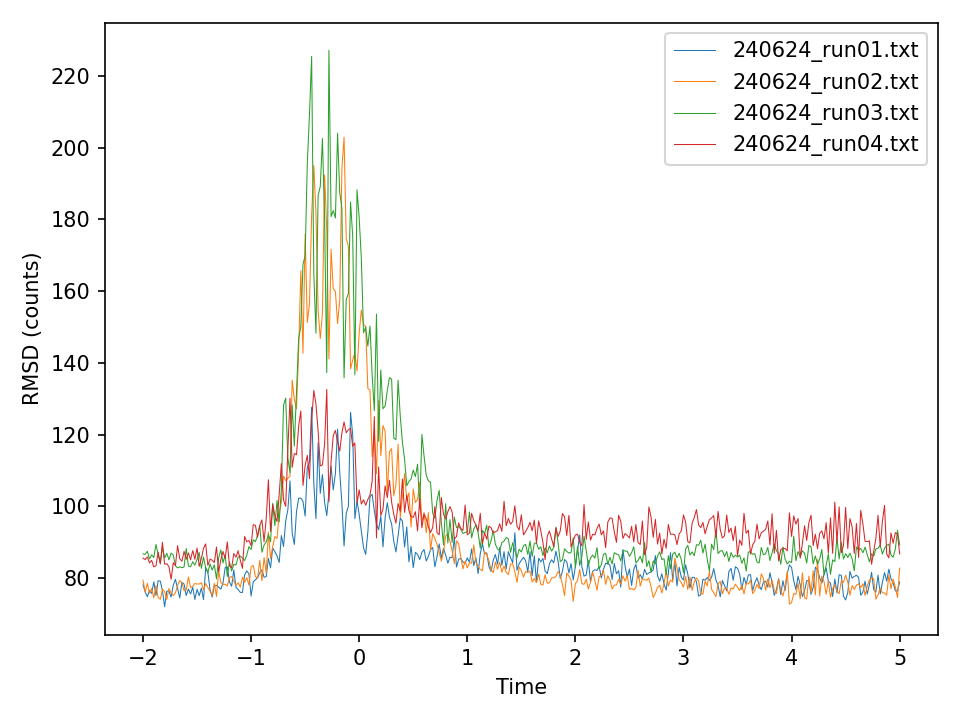

In [11]:
plt.figure(dpi=150)
plt.plot(t, rmsd.T, "-", lw=0.5, label=fnames)
plt.xlabel("Time")
plt.ylabel("RMSD (counts)")
plt.legend()
plt.tight_layout()

In [12]:
# set the threshol for rejection, and reject these pulses
# This is implemented using a "masked array" (see `numpy.ma`)
threshold = np.infty
is_bad = rmsd > threshold
sig_masked = np.ma.masked_where(
    np.broadcast_to(np.atleast_2d(is_bad)[:,np.newaxis,:], sig.shape),  # use `is_bad`, but ensure it has the correct shape
    np.ma.getdata(sig)  # get the original data from dod
)

NameError: name 'interact' is not defined

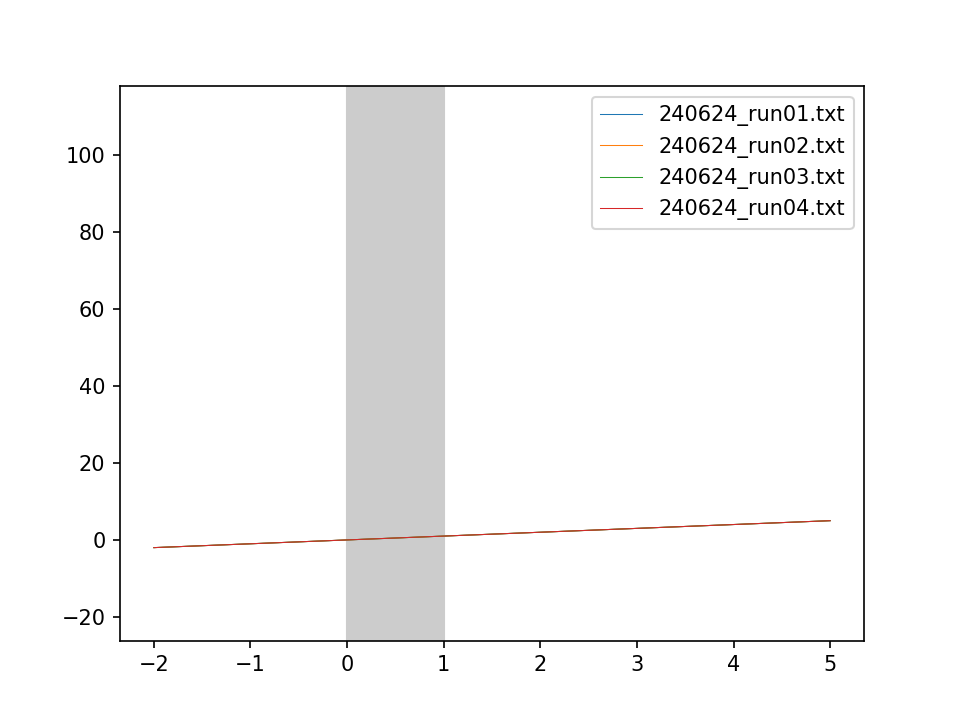

In [13]:
# Plot the kinetic transients at specific wavelength.
# the `wl` cursor controls which wl is displayed.
# The `bnds` cursor are just there to help indentify bounds for manual rejection

fig = plt.figure(dpi=150)

i = 0
ymin = np.min(sig)
ymax = np.max(sig)
curves = plt.plot(t, sig_masked[:,i,:].T, lw=0.5, label=fnames)
span = plt.axvspan(0, 1, color="0.8")
plt.ylim(ymin, ymax)
plt.legend()

idx = widgets.IntSlider(i, 0, len(pix)-1)
idx.desc_fmt = "pix = {:.02f}"


@interact(i=idx, bnds = widgets.IntRangeSlider(value=[0,1], min=0, max=len(t)-1))
def _update(i, bnds):
    for j, c in enumerate(curves):
        c.set_ydata(sig_masked[j,i,:])
    idx.description = idx.desc_fmt.format(pix[i])
    lo, hi = bnds
    span.xy[[0,1,4],0] = t[lo]
    span.xy[[2,3],0] = t[hi]

In [ ]:
# You can reject specific pulses manually like in the lines below.
# We assign the value `np.ma.masked` to slices in dod_masked. This masks the value/
# The slice is as follows: [file_index, all the spectrum, a range indices]
# file_index is the position of the file in `fnames`,
# : means do it for the whole spectrum
# range(a, b) reject indices a to b, excluding the endpoint

#ig_masked[2,:,:] = np.ma.masked  # Reject spectra 285-303 from fnames[1]
#dod_masked[3,:,range(92,100)] = np.ma.masked  # Reject spectra 320-331 from fnames[1]
#dod_masked[2,:,93]  = np.ma.masked
# dod_masked[4,:,range(65,67)] = np.ma.masked  # Reject spectra 65-67 from fnames[4]
# dod_masked[4,:,[148,]] = np.ma.masked  # Reject spectrum 148 from fnames[4]

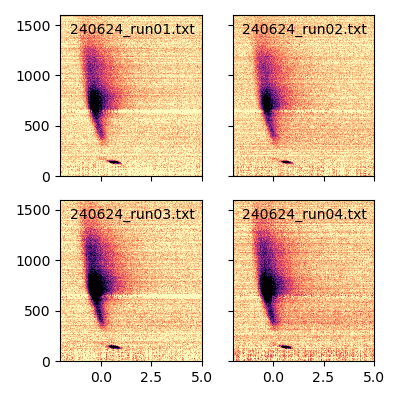

In [14]:
# Inspect the traces after rejection
nrows = ceil(len(fnames)/2)
fig, axes = plt.subplots(nrows=nrows, ncols=2, sharex=True, sharey=True, figsize=(4,nrows*2))

# You can modify the limits of the colormap here
vmin, vmax = np.percentile(sig, [10, 99])

# plot the trace for all filenames
for i, (fn, ax) in enumerate(zip(fnames, axes.flat)):
    plt.sca(ax)
    plt.pcolormesh(t, pix, sig_masked[i,:,:], cmap="magma_r", vmin=vmin, vmax=vmax)
    plt.text(0.95, 0.95, fnames[i], transform=ax.transAxes, va="top", ha="right")
plt.tight_layout()

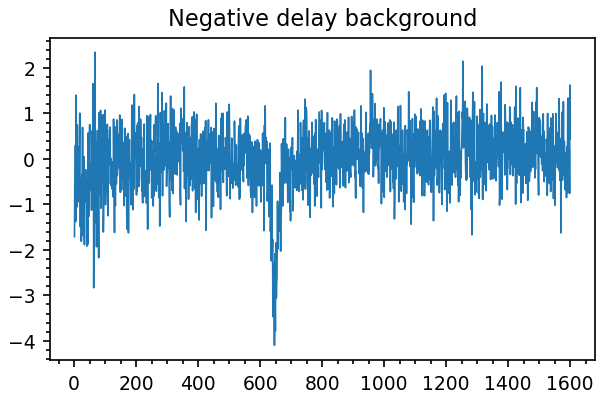

In [ ]:
# Perform the average, rejecting the masked values
avg = np.ma.mean(sig_masked, axis=0)

# remove before t0
neg_delay = np.mean(avg.compress(t<-1.4, axis=1), axis=1)
avg -= neg_delay[:,np.newaxis]
plt.figure()
plt.title("Negative delay background")
plt.plot(wl, neg_delay)

save_txt(out_root+".txt", t, wl_u, avg.T)


c:\Users\palatosa\miniconda3\envs\main\Lib\site-packages\numpy\lib\function_base.py:4823: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


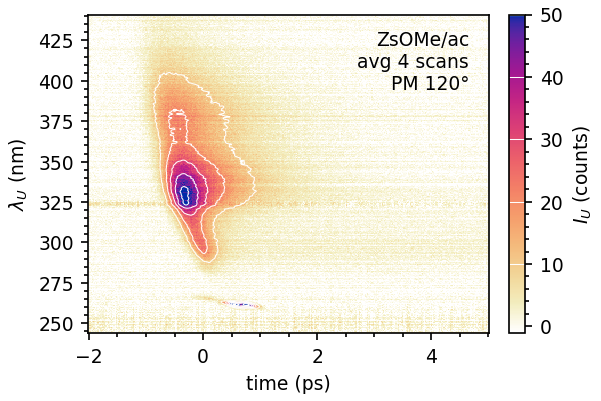

In [ ]:
# save a plot
plt.figure()
lo, hi = np.percentile(avg[300:,:], [10, 99.5])
lo = -1
hi = 50
plt.pcolormesh(t, wl_u, avg, cmap="cet_CET_L17", vmin=lo, vmax=hi)
cb = plt.colorbar(label=r"$I_U$ (counts)")
#lines = plt.contour(t, wl, savgol_filter(avg, 9, 2, axis=0), levels = np.arange(0, np.max(avg), hi/4)[1:], colors="w", linewidths=0.5)
lines = plt.contour(t, wl_u, gaussian_filter(avg, [3, 1]), levels = np.arange(0, hi*2,10)[1:], colors="w", linewidths=0.5)
cb.add_lines(lines)
plt.xlabel("time (ps)")
plt.ylabel(r"$\lambda_U$ (nm)")
plt.text(0.95, 0.95, "ZsOMe/ac\navg 4 scans\nPM 120°", transform=plt.gca().transAxes, va="top", ha="right")
#plt.tight_layout()
plt.savefig(out_root+"_avg.png", dpi=300)

# t0 correction

In [ ]:
wl_t0, t0c = np.loadtxt("240624_t0_sell_NWG320.txt").T
assert np.allclose(wl_u, wl_t0)
t_s, shifted = shift_trace(t, avg, t0c)

FileNotFoundError: 240624_t0_sell_NWG320.txt not found.

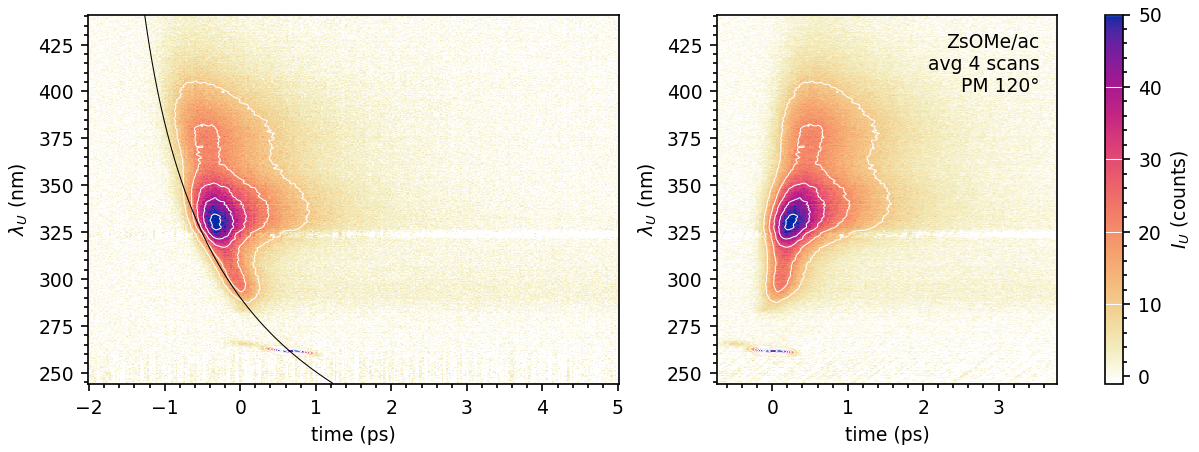

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(8,3), width_ratios = [t[-1]-t[0], t_s[-1]-t_s[0]])
plt.sca(axes[0])
lo, hi = np.percentile(avg[300:,:], [10, 99.5])
lo = -1
hi = 50
plt.pcolormesh(t, wl_u, avg, cmap="cet_CET_L17", vmin=lo, vmax=hi)
#cb = plt.colorbar(label=r"$I_U$ (counts)")
#lines = plt.contour(t, wl, savgol_filter(avg, 9, 2, axis=0), levels = np.arange(0, np.max(avg), hi/4)[1:], colors="w", linewidths=0.5)
lines = plt.contour(t, wl_u, gaussian_filter(avg, [3, 1]), levels = np.arange(0, hi*2,10)[1:], colors="w", linewidths=0.5)
plt.plot(t0c, wl_t0, color="k", lw=0.5)
plt.xlabel("time (ps)")
plt.ylabel(r"$\lambda_U$ (nm)")

plt.sca(axes[1])
plt.pcolormesh(t_s, wl_u, shifted, cmap="cet_CET_L17", vmin=lo, vmax=hi)
cb = plt.colorbar(label=r"$I_U$ (counts)", ax=axes)
#lines = plt.contour(t, wl, savgol_filter(avg, 9, 2, axis=0), levels = np.arange(0, np.max(avg), hi/4)[1:], colors="w", linewidths=0.5)
lines = plt.contour(t_s, wl_u, gaussian_filter(shifted, [3, 1]), levels = np.arange(0, hi*2,10)[1:], colors="w", linewidths=0.5)
plt.xlabel("time (ps)")
plt.ylabel(r"$\lambda_U$ (nm)")

cb.add_lines(lines)
plt.text(0.95, 0.95, "ZsOMe/ac\navg 4 scans\nPM 120°", transform=plt.gca().transAxes, va="top", ha="right")
#plt.tight_layout()
plt.savefig(out_root+"_avg.png", dpi=300)

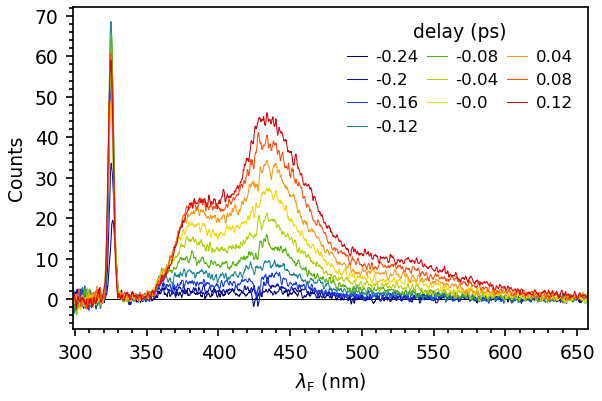

In [ ]:
selected = np.arange(-0.24, 0.1201, 0.04)
wl_f = 1/(1/wl_u-1/1340)
plt.figure()
palette = plt.get_cmap("cet_CET_R4")(np.linspace(0, 1, len(selected)))
palette = dict(zip(selected, palette))
plt.axhline(0, color="k", lw=0.5)
for s_ in selected:
    i = argnear(t_s, s_)
    plt.plot(wl_f, savgol_filter(shifted[:,i], 11, 2), c=palette[s_], lw=0.5, label=t_s[i])
plt.legend(ncols=3, title="delay (ps)")
plt.xlim(wl_f[0], wl_f[-1])
plt.xlabel("$\lambda_\mathrm{F}$ (nm)")
plt.ylabel("Counts")
plt.savefig("240624_OMeZs_spec_uc_1.png", dpi=600)

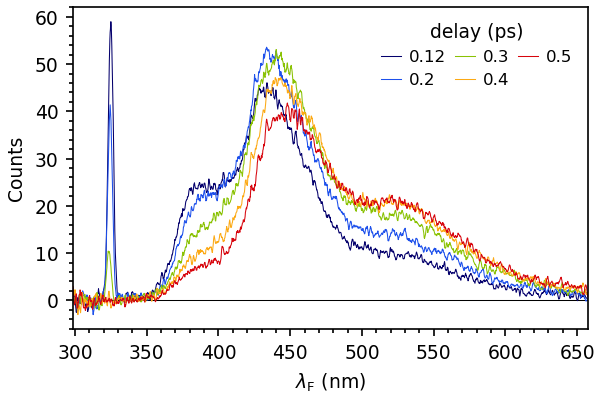

In [ ]:
selected = [0.12, 0.2, 0.3, 0.4, 0.5]
plt.figure()
palette = plt.get_cmap("cet_CET_R4")(np.linspace(0, 1, len(selected)))
palette = dict(zip(selected, palette))
plt.axhline(0, color="k", lw=0.5)
for s_ in selected:
    i = argnear(t_s, s_)
    plt.plot(wl_f, savgol_filter(shifted[:,i], 11, 2), c=palette[s_], lw=0.5, label=t_s[i])
plt.legend(ncols=3, title="delay (ps)")
plt.xlim(wl_f[0], wl_f[-1])
plt.xlabel("$\lambda_\mathrm{F}$ (nm)")
plt.ylabel("Counts")
plt.savefig("240624_OMeZs_spec_uc_2.png", dpi=600) 

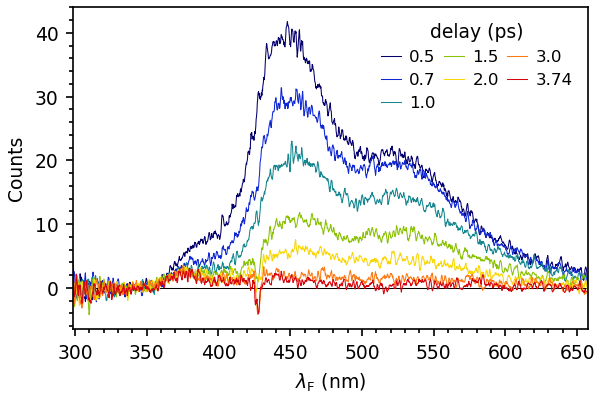

In [ ]:
selected = np.arange(0.5, 3, 0.2)
selected = [0.5, 0.7, 1, 1.5, 2, 3, 3.75]
plt.figure()
palette = plt.get_cmap("cet_CET_R4")(np.linspace(0, 1, len(selected)))
palette = dict(zip(selected, palette))
plt.axhline(0, color="k", lw=0.5)
for s_ in selected:
    i = argnear(t_s, s_)
    plt.plot(wl_f, savgol_filter(shifted[:,i], 11, 2), c=palette[s_], lw=0.5, label=t_s[i])
plt.legend(ncols=3, title="delay (ps)")
plt.xlim(wl_f[0], wl_f[-1])
plt.xlabel("$\lambda_\mathrm{F}$ (nm)")
plt.ylabel("Counts")
plt.savefig("240624_OMeZs_spec_uc_3.png", dpi=600) 